imports and load dataset

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import shap

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv(
    "../data/insurance-data.csv",
    sep="|"
)
df.columns = df.columns.str.strip()

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


data cleaning missing and drop high null

In [31]:
df.isnull().sum()
df["TotalClaims"] = pd.to_numeric(
    df["TotalClaims"],
    errors="coerce"
)

df["TotalPremium"] = pd.to_numeric(
    df["TotalPremium"],
    errors="coerce"
)
df = df.dropna(
    subset=[
        "TotalClaims",
        "TotalPremium"
    ]
)

feature engineering vehicle age ,marigin and claim indicator

In [32]:
df["VehicleAge"] = 2015 - df["RegistrationYear"]
df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)
df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)
df["HasClaim"] = np.where(
    df["TotalClaims"] > 0,
    1,
    0
)
claims_df = df[
    df["TotalClaims"] > 0
]

select features

In [33]:
features = [
    "TotalPremium",
    "CustomValueEstimate",
    "kilowatts",
    "cubiccapacity",
    "VehicleAge"
]
model_df = claims_df[
    features + ["TotalClaims"]
]

model_df = model_df.dropna()
X = model_df[features]

y = model_df["TotalClaims"]

split train and test

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


linear regression and evaluation

In [35]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_preds)
)

lr_r2 = r2_score(y_test, lr_preds)

print("RMSE:", lr_rmse)
print("R2:", lr_r2)

RMSE: 42037.40330587276
R2: 0.2511452867208084


random forest and evaluation

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_r2 = r2_score(y_test, rf_preds)

print("RMSE:", rf_rmse)
print("R2:", rf_r2)

RMSE: 44674.32200519137
R2: 0.15425050865498846


xg boost evaluation

In [37]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgb_r2 = r2_score(y_test, xgb_preds)

print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

RMSE: 47210.06807343557
R2: 0.055515014863175005


model comparison table

In [38]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,42037.403306,0.251145
1,Random Forest,44674.322005,0.154251
2,XGBoost,47210.068073,0.055515


feature importance plot

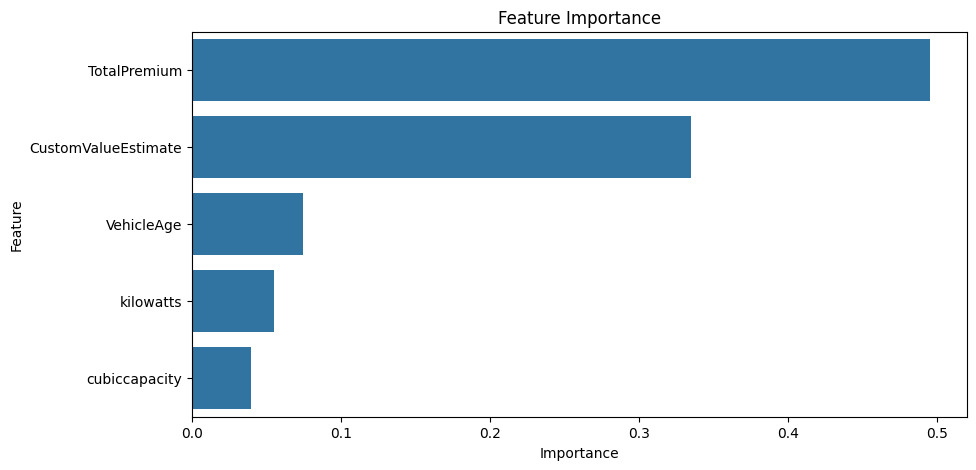

In [39]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df
plt.figure(figsize=(10, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

shap analysis and summary plot

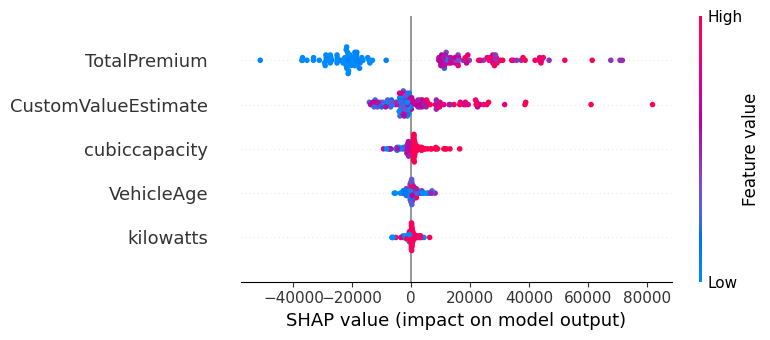

In [40]:
explainer = shap.Explainer(rf_model)

shap_values = explainer(X_test)
shap.summary_plot(
    shap_values,
    X_test
)

 Business Interpretation

The Random Forest and XGBoost models performed better than Linear Regression, indicating that insurance claim severity depends on non-linear relationships between customer, vehicle, and policy characteristics.

Feature importance analysis showed that TotalPremium, VehicleAge, and CustomValueEstimate were among the strongest predictors of claim severity.

SHAP analysis revealed that older vehicles and higher insured values generally increase predicted claim amounts. This suggests that vehicle condition and replacement cost significantly influence insurance risk and should be incorporated into dynamic pricing strategies.